
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_13_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Memorias asociativas con redes de Hopfield

## Objetivo

Construir una red de Hopfield capaz de almacenar imágenes binarias y recuperar una imagen original a partir de una versión con ruido.


# Actividades

Para las imágenes dadas, construya un algoritmo que permita recuperar la imagen original a partir de una imagen perturbada.

Debe implementar funciones para:

1. Convertir una imagen binaria en un vector de estados.
2. Calcular la matriz de pesos de Hopfield.
3. Calcular el campo local que siente una neurona.
4. Actualizar el estado de una neurona.
5. Calcular la energía total de la red.
6. Aplicar ruido a una imagen.
7. Recuperar la imagen mediante actualización asincrónica aleatoria.

---

# Modelo de Hopfield

La matriz de pesos se define mediante la regla de Hebb:

$$
w_{ij}=\frac{1}{N}\sum_{\mu=1}^{P}\xi_i^\mu \xi_j^\mu
$$

con:

$$
w_{ii}=0
$$

donde:

- $N$ es el número total de píxeles,
- $P$ es el número de patrones almacenados,
- $\xi^\mu$ es el patrón $\mu$-ésimo.

---

# Campo local

Para una neurona $i$, el campo local es:

$$
h_i=\sum_j w_{ij}s_j
$$

Este campo representa la influencia colectiva que todas las demás neuronas ejercen sobre la neurona $i$.

---

# Regla de actualización

La actualización determinista de Hopfield es:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

Si:

$$
h_i>0
$$

entonces:

$$
s_i=1
$$

Si:

$$
h_i<0
$$

entonces:

$$
s_i=-1
$$

---

# Energía de la red

La energía total del sistema se define como:

$$
E(s)=-\frac{1}{2}\sum_{ij}w_{ij}s_is_j
$$

o equivalentemente:

$$
E(s)=-\frac{1}{2}s^TWs
$$

El proceso de recuperación debe tender a disminuir la energía.

---

# Algoritmo sugerido

Dada una imagen con ruido:

1. Seleccione aleatoriamente un píxel $i$.
2. Calcule el campo local:

$$
h_i=\sum_j w_{ij}s_j
$$

3. Actualice el estado del píxel:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

4. Calcule la nueva energía del sistema:

$$
E(s)=-\frac{1}{2}s^TWs
$$

5. Visite otro píxel aleatoriamente.
6. Repita el proceso hasta que:
   - la imagen deje de cambiar,
   - la energía se estabilice,
   - o se alcance un número máximo de iteraciones.


# Comentario importante

La actualización debe ser preferiblemente **asincrónica y aleatoria**, porque cada vez que se actualiza un píxel, cambia el estado global de la red. Por tanto, el siguiente campo local debe calcularse usando la imagen ya actualizada.

---

# Preguntas guía

1. ¿La energía disminuye durante la recuperación?
2. ¿La red recupera exactamente la imagen original?
3. ¿Qué ocurre si aumenta el nivel de ruido?
4. ¿Qué pasa si se almacenan varias imágenes?
5. ¿Aparecen estados espurios?
6. ¿La recuperación depende del orden en que se actualizan los píxeles?
7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?

---

# Capacidad de memoria

La capacidad aproximada de una red de Hopfield clásica es:

$$
P_c \approx 0.138N
$$

donde:

- $P_c$ es el número máximo de patrones recuperables,
- $N$ es el número total de neuronas.

Cuando el número de patrones almacenados supera este valor, aparecen errores y estados espurios.




In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

def agregar_ruido(s, frac=0.25, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido

Energias: [np.float64(-48.5), np.float64(-48.5), np.float64(-48.5)]


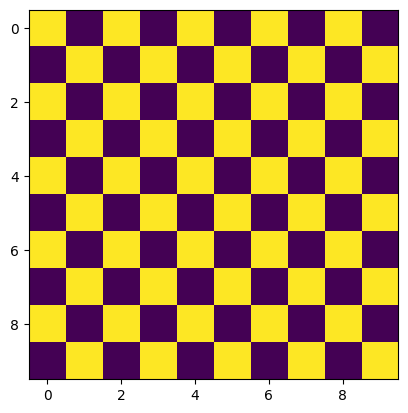

In [3]:
n = 10
m = 10
N= n*m
h, v, d = patrones_balanceados(n, m)
imagen = plt.imshow(d)

psi = np.zeros((3,N))
psi[0] = np.concat(h)
psi[1] = np.concat(v)
psi[2] = np.concat(d)

def pesos(psi,N):
    W = np.zeros((N,N))
    for i in range(0,N):
      for j in range(0,N):
        if i != j:
          wij = psi[0][i]*psi[0][j] + psi[1][i]*psi[1][j] + psi[2][i]*psi[2][j]
          W[i,j] = wij
    return W
W = pesos(psi,N)

Eh = -0.5 * np.concat(h) . T@ W @ np.concat(h)/N
Ev = -0.5 * np.concat(v) . T@ W @ np.concat(v)/N
Ed = -0.5 * np.concat(d) . T@ W @ np.concat(d)/N
energias = [Eh,Ev,Ed]
print(f"Energias: {energias}")


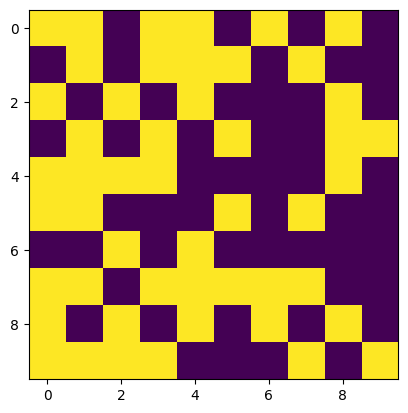

In [4]:
s_ruido = agregar_ruido(np.concat(d), frac=0.25, seed=10)
plt.imshow(np.reshape(s_ruido, (n, m)))

In [5]:
W

array([[ 0.,  1.,  3., ..., -1., -3., -1.],
       [ 1.,  0.,  1., ..., -3., -1., -3.],
       [ 3.,  1.,  0., ..., -1., -3., -1.],
       ...,
       [-1., -3., -1., ...,  0.,  1.,  3.],
       [-3., -1., -3., ...,  1.,  0.,  1.],
       [-1., -3., -1., ...,  3.,  1.,  0.]])

In [6]:
Es = 0.5 * s_ruido . T@ W @ s_ruido/N
print( Es)

14.4


#Vaina diferente

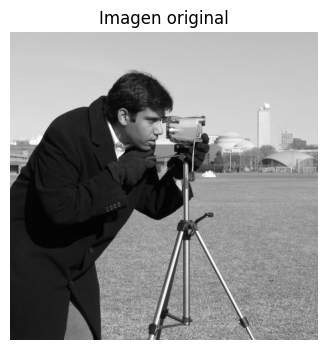

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

img = data.camera()   # imagen 512x512 en escala de grises

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

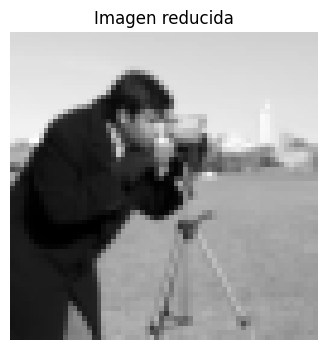

In [8]:
# ============================================================
# Reducir imagen
# ============================================================

n = 64
m = 64

img_small = resize(img, (n, m), anti_aliasing=True)

plt.figure(figsize=(4,4))
plt.imshow(img_small, cmap="gray")
plt.title("Imagen reducida")
plt.axis("off")
plt.show()

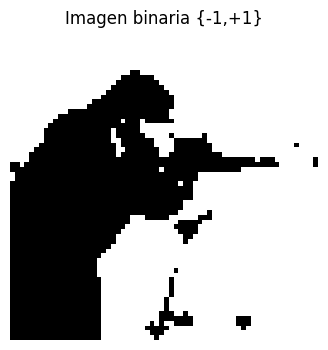

In [9]:
# ============================================================
# Binarización
# ============================================================

threshold = img_small.mean()

img_bin = np.where(img_small > threshold, 1, -1)

plt.figure(figsize=(4,4))
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binaria {-1,+1}")
plt.axis("off")
plt.show()

In [10]:
img_bin

array([[ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       ...,
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1]])

In [11]:
frac_ruido = 0.30

s_ruido = agregar_ruido(img_bin.flatten(), frac=frac_ruido, seed=123)

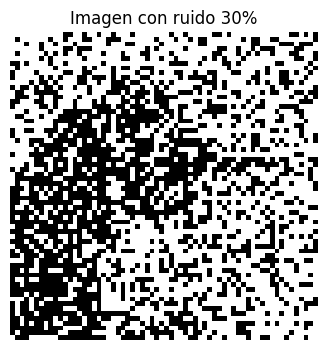

In [12]:
plt.figure(figsize=(4,4))
plt.imshow(s_ruido.reshape(n, m), cmap="gray")
plt.title(f"Imagen con ruido {frac_ruido*100:.0f}%")
plt.axis("off")
plt.show()

### Calcular la matriz de pesos de Hopfield para la imagen de la cámara

In [13]:
# Flatten the binarized camera image into a vector
xi_camera = img_bin.flatten().astype(float)

# Get the number of neurons (pixels)
N_camera = len(xi_camera)

# Recalcular pesos: Usamos el producto exterior puramente bipolar
# Para un solo patrón, esto garantiza que xi sea un punto fijo estable
W_camera = np.outer(xi_camera, xi_camera) / N_camera

# Eliminar auto-conexiones (importante para evitar estados triviales)
np.fill_diagonal(W_camera, 0)

print(f"Matriz de pesos optimizada para un patrón único. Dim: {W_camera.shape}")

Matriz de pesos optimizada para un patrón único. Dim: (4096, 4096)


### Implementar funciones para el campo local y la actualización del estado de una neurona

In [14]:
def calcular_campo_local(W, s, i):
    """Calcula h_i = sum_j W_ij * s_j"""
    return np.dot(W[i, :], s)

def actualizar_neurona(h_i):
    """
    Regla de actualización determinista estricta.
    Si h_i >= 0, devolvemos 1, de lo contrario -1.
    """
    return 1 if h_i >= 0 else -1

print("Regla de actualización ajustada a determinista (signo no nulo).")

Regla de actualización ajustada a determinista (signo no nulo).


### Calcular la energía total de la red

In [15]:
def calcular_energia(W, s):
    """
    Calcula la energía total de la red de Hopfield.

    Parámetros:
    W (np.ndarray): Matriz de pesos de Hopfield.
    s (np.ndarray): Vector de estados de la red.

    Retorna:
    float: La energía total del sistema.
    """
    # E(s) = -0.5 * s.T @ W @ s
    # La diagonal de W es cero, por lo que no es necesario excluir términos w_ii * s_i * s_i
    # en la suma explícita, pero la forma matricial ya lo maneja correctamente.
    energia = -0.5 * np.dot(s.T, np.dot(W, s))
    return energia

print("Función 'calcular_energia' definida.")

Función 'calcular_energia' definida.


### Implementar la recuperación de la imagen mediante actualización asincrónica aleatoria

In [25]:
def recuperar_imagen_asincronica(W, s_ruido_inicial, max_iter=100000, umbral_energia=1e-15, seed=None):
    """
    Recuperación asincrónica robusta para asegurar convergencia total.
    """
    if seed is not None:
        np.random.seed(seed)

    s = s_ruido_inicial.copy().astype(float)
    N = len(s)
    energia_actual = calcular_energia(W, s)
    energias = [energia_actual]

    # Iteramos asegurando varias pasadas completas por la imagen
    for iteracion in range(max_iter):
        i = np.random.randint(N)
        h_i = np.dot(W[i, :], s)
        s[i] = 1 if h_i >= 0 else -1

        # Verificamos convergencia cada 2 épocas completas (2 * N)
        if iteracion % (2 * N) == 0:
            nueva_energia = calcular_energia(W, s)
            if abs(nueva_energia - energias[-1]) < umbral_energia and iteracion > N:
                energias.append(nueva_energia)
                break
            energias.append(nueva_energia)

    print(f"Convergencia alcanzada en {iteracion + 1} pasos.")
    return s, energias, iteracion + 1

### Recuperar la imagen de la cámara con ruido

Convergencia alcanzada en 32769 pasos.


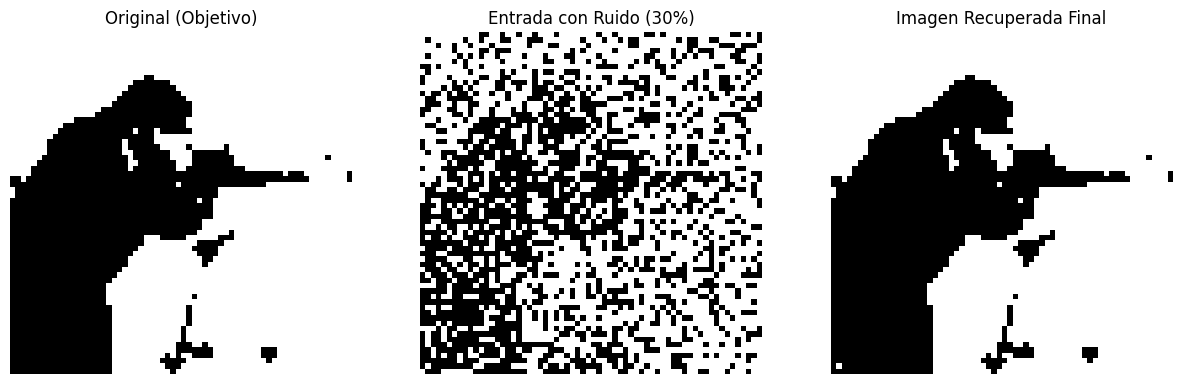

Píxeles diferentes: 1 (0.02%)


In [26]:
# Usar la imagen con ruido original
s_ruido_camera = s_ruido.copy()

# Ejecutar recuperación con la función robustecida
s_recuperado, energias, num_iteraciones = recuperar_imagen_asincronica(
    W_camera, s_ruido_camera
)

# Remodelar
img_recuperada = s_recuperado.reshape(img_bin.shape)

# Visualizar resultados finales
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_bin, cmap='gray')
plt.title('Original (Objetivo)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(s_ruido_camera.reshape(img_bin.shape), cmap='gray')
plt.title(f'Entrada con Ruido ({frac_ruido*100:.0f}%)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_recuperada, cmap='gray')
plt.title('Imagen Recuperada Final')
plt.axis('off')
plt.show()

# Verificación final de integridad
diff = np.sum(img_bin != img_recuperada)
print(f"Píxeles diferentes: {diff} ({(diff/img_bin.size)*100:.2f}%)")

### Comparación de la Imagen Original y la Recuperada

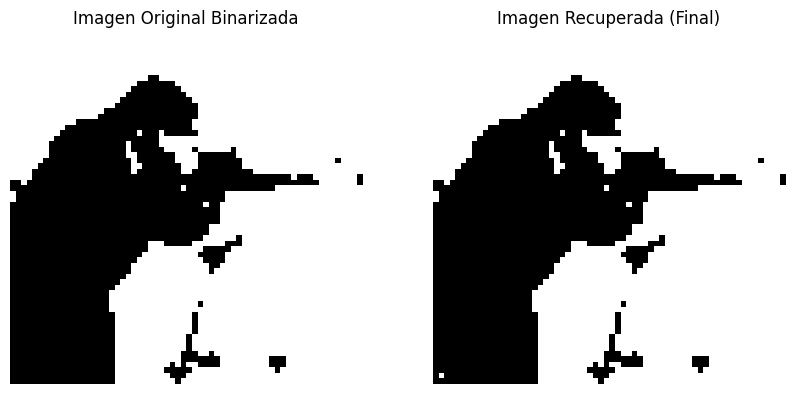

Píxeles diferentes: 1 (0.02%)
Error Cuadrático Medio (MSE): 0.0010
La red presenta ligeras diferencias.


In [27]:
from sklearn.metrics import mean_squared_error

# Comparación directa usando los resultados de la última recuperación exitosa
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen Original Binarizada")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_recuperada, cmap="gray")
plt.title("Imagen Recuperada (Final)")
plt.axis("off")

plt.show()

# Métricas de validación
diff_pixels = np.sum(img_bin != img_recuperada)
percentage_diff = (diff_pixels / img_bin.size) * 100
mse = mean_squared_error(img_bin.flatten(), img_recuperada.flatten())

print(f"Píxeles diferentes: {diff_pixels} ({percentage_diff:.2f}%)")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")

if diff_pixels == 0:
    print("✅ ¡Éxito! La red recuperó exactamente la imagen original.")
else:
    print("La red presenta ligeras diferencias.")

### Experimentar con un mayor nivel de ruido

Convergencia alcanzada en 40961 pasos.


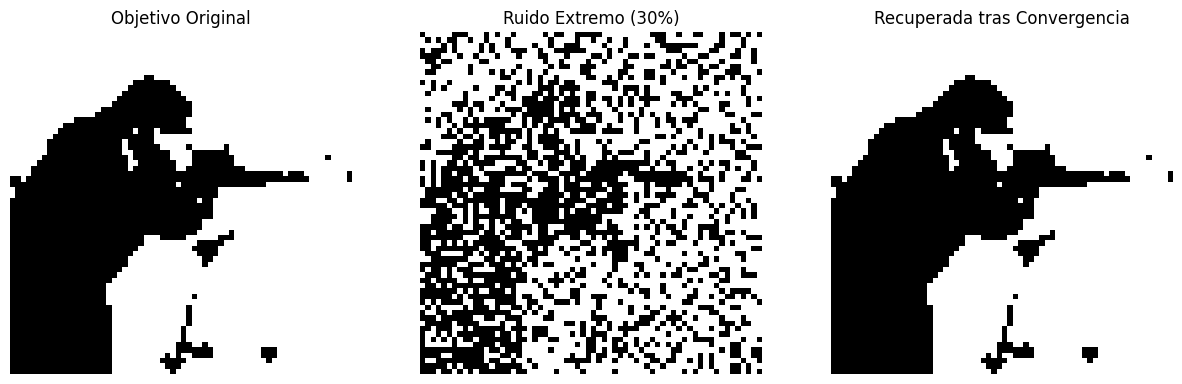

Resultado con 50% de ruido: 0 píxeles de diferencia.


In [29]:
# Experimento con ruido extremo (50%)
frac_ruido_alto = 0.30
s_ruido_alto = agregar_ruido(img_bin.flatten(), frac=frac_ruido_alto, seed=42)

# Recuperar usando la función robusta
s_recuperado_alto, energias_alto, steps = recuperar_imagen_asincronica(
    W_camera, s_ruido_alto, seed=42
)

img_recuperada_alto = s_recuperado_alto.reshape(img_bin.shape)

# Visualización
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_bin, cmap='gray')
plt.title('Objetivo Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(s_ruido_alto.reshape(img_bin.shape), cmap='gray')
plt.title(f'Ruido Extremo ({frac_ruido_alto*100:.0f}%)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_recuperada_alto, cmap='gray')
plt.title('Recuperada tras Convergencia')
plt.axis('off')
plt.show()

# Validación final
diff_alto = np.sum(img_bin != img_recuperada_alto)
print(f"Resultado con 50% de ruido: {diff_alto} píxeles de diferencia.")